<a href="https://colab.research.google.com/github/ArthTechX/Diffusion-Language-Models/blob/main/week4_norgate_pareto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 — NoR-Gate: λ(t), learned bounded λ(t), gate regularizers, Pareto comparison

This notebook implements the Week 4 work plan:

1. **Three-bin λ(t) schedule** for low/mid/high timestep-noise bins.
2. **Learned bounded λ(t)** using a tiny trainable MLP constrained to `[λ_min, λ_max]`.
3. **Actual gate regularizers** using real DG+LoRA gates:
   - frozen-branch anchor: `-log(alpha_frozen)`
   - entropy regularizer: `H(alpha_frozen, alpha_grown)`
4. **Pareto plot** comparing:
   - fixed DG+LoRA
   - DASG
   - NoR-Gate with three-bin λ(t)
   - NoR-Gate with learned bounded λ(t)

Designed for free Colab T4 using `inclusionAI/LLaDA-MoE-7B-A1B-Instruct` with 4-bit NF4 loading.

## 0. GPU check

In [1]:
!nvidia-smi

Wed Jul 15 08:20:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Install dependencies

Run this cell, then restart the runtime: `Runtime → Restart session`. After restart, continue from Section 2.

In [2]:
!pip uninstall -y transformers tokenizers -q

!pip -q install --no-cache-dir \
  "transformers>=4.45.0,<5.0.0" \
  "bitsandbytes>=0.46.1" \
  accelerate \
  safetensors \
  sentencepiece \
  einops \
  huggingface_hub \
  pandas \
  matplotlib \
  numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 194.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 187.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 459.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 206.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


## 2. Imports and configuration

In [3]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc, json, math, time, random
from pathlib import Path
from contextlib import contextmanager

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_NAME = "inclusionAI/LLaDA-MoE-7B-A1B-Instruct"
MASK_ID = 156895
MAX_LENGTH = 32
OUT_DIR = Path("/content/week4_norgate_pareto")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_STEPS = 3
LR = 2e-4
LORA_RANK = 4
LORA_ALPHA = 8
LORA_DROPOUT = 0.05
LAMBDA_MIN = 0.05
LAMBDA_MAX = 1.25
BETA_FROZEN_ANCHOR = 0.05
BETA_ENTROPY = 0.01

NOISE_BINS = {"low_noise": 0.15, "mid_noise": 0.50, "high_noise": 0.85}
NOISE_BIN_TO_IDX = {"low_noise": 0, "mid_noise": 1, "high_noise": 2}
THREE_BIN_LAMBDA = {"low_noise": 0.10, "mid_noise": 0.50, "high_noise": 1.00}
FIXED_LAMBDA = {"low_noise": 0.50, "mid_noise": 0.50, "high_noise": 0.50}

DOMAINS = {
    "code_toy": [
        "def add_numbers(a, b): return a + b",
        "for i in range(n): total += arr[i]",
        "A binary search repeatedly halves the search interval.",
    ],
    "math_toy": [
        "The derivative of x squared is two x.",
        "A matrix product uses rows of the first matrix and columns of the second.",
        "The sum of angles in a triangle is one hundred eighty degrees.",
    ],
    "qa_toy": [
        "Question: What is the capital of France? Answer: Paris.",
        "Question: What gas do plants absorb? Answer: Carbon dioxide.",
        "Question: Who wrote Hamlet? Answer: William Shakespeare.",
    ],
}
RETENTION_TEXTS = [
    "The city library opens every morning.",
    "Students learn better when examples are clear and practice is consistent.",
    "A healthy diet includes fruits, vegetables, grains, and enough water.",
]
print("Output dir:", OUT_DIR)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Output dir: /content/week4_norgate_pareto
GPU: Tesla T4


## 3. Load DASG-selected layers from Week 3

In [4]:
def load_dasg_layers_from_week3(default_layers=[15, 14, 13, 12, 11]):
    week3_path = Path("/content/week3_dasg_budget_sweeps/week3_selected_layers_by_rule_budget.csv")
    if not week3_path.exists():
        print("Week 3 selected-layer file not found. Using fallback:", default_layers)
        return default_layers
    df = pd.read_csv(week3_path)
    print("Loaded Week 3 selections:", week3_path)
    display(df.head())
    rule_col = budget_col = layers_col = None
    for col in df.columns:
        lc = col.lower()
        if "rule" in lc: rule_col = col
        if "budget" in lc: budget_col = col
        if "layer" in lc and ("selected" in lc or "layers" in lc): layers_col = col
    if layers_col is None:
        return default_layers
    chosen = df.copy()
    if rule_col is not None:
        chosen = chosen[chosen[rule_col].astype(str).str.contains("combined", case=False, na=False)]
    if budget_col is not None and len(chosen) > 0:
        chosen["_budget_float"] = chosen[budget_col].astype(float)
        chosen = chosen.iloc[(chosen["_budget_float"] - 0.5).abs().argsort()[:1]]
    elif len(chosen) > 0:
        chosen = chosen.head(1)
    if len(chosen) == 0: return default_layers
    raw = chosen.iloc[0][layers_col]
    if isinstance(raw, str):
        cleaned = raw.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
        layers = [int(x.strip()) for x in cleaned.split(",") if x.strip().lstrip('-').isdigit()]
    else:
        layers = default_layers
    return layers if layers else default_layers

DASG_LAYERS = load_dasg_layers_from_week3()
NUM_BLOCKS_ASSUMED = 16
FIXED_LATE_LAYERS = list(range(NUM_BLOCKS_ASSUMED - len(DASG_LAYERS), NUM_BLOCKS_ASSUMED))
print("DASG_LAYERS:", DASG_LAYERS)
print("FIXED_LATE_LAYERS:", FIXED_LATE_LAYERS)

Week 3 selected-layer file not found. Using fallback: [15, 14, 13, 12, 11]
DASG_LAYERS: [15, 14, 13, 12, 11]
FIXED_LATE_LAYERS: [11, 12, 13, 14, 15]


## 4. Load tokenizer and model helpers

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
print("Tokenizer loaded.")

def cleanup_model():
    global model
    try: del model
    except Exception: pass
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def load_base_model():
    cleanup_model()
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    base = AutoModel.from_pretrained(
        MODEL_NAME,
        trust_remote_code=True,
        quantization_config=bnb_config,
        device_map="auto",
        max_memory={0: "13GiB", "cpu": "25GiB"},
        low_cpu_mem_usage=True,
    )
    base.eval()
    return base

def get_input_device(model):
    try: return model.get_input_embeddings().weight.device
    except Exception: pass
    if hasattr(model, "device"): return model.device
    for p in model.parameters(): return p.device
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def gpu_mem_gb():
    return torch.cuda.max_memory_allocated() / 1024**3 if torch.cuda.is_available() else 0.0

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Tokenizer loaded.


## 5. Masking and loss helpers

In [6]:
def encode_text(text, model):
    input_device = get_input_device(model)
    batch = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH)
    input_ids = batch["input_ids"].to(input_device)
    attention_mask = batch.get("attention_mask", torch.ones_like(input_ids)).to(input_device)
    return input_ids, attention_mask

def make_masked_input(clean_ids, attention_mask, mask_prob):
    rand = torch.rand(clean_ids.shape, device=clean_ids.device)
    valid = attention_mask.bool()
    masked_indices = (rand < mask_prob) & valid
    if not masked_indices.any(): masked_indices[0, -1] = True
    noisy_ids = torch.where(masked_indices, torch.full_like(clean_ids, MASK_ID), clean_ids)
    return noisy_ids, masked_indices

def get_logits_from_output(out):
    if hasattr(out, "logits"): return out.logits
    if isinstance(out, (tuple, list)): return out[0]
    return out

def forward_logits(model, input_ids):
    return get_logits_from_output(model(input_ids=input_ids))

def masked_weighted_ce(logits, labels, masked_indices, mask_prob):
    if masked_indices.sum().item() == 0:
        zero = torch.tensor(0.0, device=logits.device)
        return zero, zero
    ce = F.cross_entropy(logits[masked_indices].float(), labels[masked_indices])
    return ce / mask_prob, ce

def teacher_agreement(student_logits, teacher_logits, masked_indices):
    if masked_indices.sum().item() == 0: return float("nan")
    return (student_logits.argmax(-1)[masked_indices] == teacher_logits.argmax(-1)[masked_indices]).float().mean().item()

## 6. Actual DG+LoRA gated module

In [7]:
class DGGatedLoRALinear(nn.Module):
    def __init__(self, base_layer, r=4, lora_alpha=8, lora_dropout=0.05):
        super().__init__()
        if not hasattr(base_layer, "in_features") or not hasattr(base_layer, "out_features"):
            raise ValueError("Base layer must expose in_features and out_features.")
        self.base_layer = base_layer
        self.in_features = int(base_layer.in_features)
        self.out_features = int(base_layer.out_features)
        self.r = int(r)
        self.scaling = float(lora_alpha) / float(r)
        for p in self.base_layer.parameters(): p.requires_grad = False
        try: device = base_layer.weight.device
        except Exception: device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.lora_A = nn.Linear(self.in_features, self.r, bias=False).to(device=device, dtype=torch.float32)
        self.lora_B = nn.Linear(self.r, self.out_features, bias=False).to(device=device, dtype=torch.float32)
        self.dropout = nn.Dropout(lora_dropout)
        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)
        self.gate_logits = nn.Parameter(torch.tensor([-0.5, -1.0, -2.0], device=device, dtype=torch.float32))
        self.register_buffer("noise_bin_idx", torch.tensor(0, dtype=torch.long, device=device), persistent=False)
        self.adapter_disabled = False
    def set_noise_bin_idx(self, idx):
        self.noise_bin_idx.fill_(int(idx))
    def alpha_grown_tensor(self):
        if self.adapter_disabled:
            return torch.zeros((), device=self.noise_bin_idx.device, dtype=torch.float32)
        return torch.sigmoid(self.gate_logits[int(self.noise_bin_idx.item())])
    def alpha_frozen_tensor(self):
        return 1.0 - self.alpha_grown_tensor()
    def gate_entropy_tensor(self, eps=1e-8):
        a_g = self.alpha_grown_tensor().clamp(eps, 1.0 - eps)
        a_f = (1.0 - a_g).clamp(eps, 1.0 - eps)
        probs = torch.stack([a_f, a_g])
        return -(probs * torch.log(probs)).sum()
    def forward(self, x, *args, **kwargs):
        frozen_out = self.base_layer(x, *args, **kwargs)
        if self.adapter_disabled: return frozen_out
        delta = self.lora_B(self.lora_A(self.dropout(x.to(self.lora_A.weight.dtype)))) * self.scaling
        return frozen_out + self.alpha_grown_tensor().to(frozen_out.dtype) * delta.to(frozen_out.dtype)

def iter_dg_modules(model):
    for module in model.modules():
        if isinstance(module, DGGatedLoRALinear): yield module

def set_noise_bin(model, noise_bin):
    idx = NOISE_BIN_TO_IDX[noise_bin]
    for m in iter_dg_modules(model): m.set_noise_bin_idx(idx)

@contextmanager
def disable_adapters(model):
    modules = list(iter_dg_modules(model))
    old_values = [m.adapter_disabled for m in modules]
    try:
        for m in modules: m.adapter_disabled = True
        yield
    finally:
        for m, old in zip(modules, old_values): m.adapter_disabled = old

def gate_regularizer(model, beta_anchor=0.0, beta_entropy=0.0, eps=1e-8):
    modules = list(iter_dg_modules(model))
    if len(modules) == 0:
        z = torch.tensor(0.0, device=get_input_device(model))
        return z, z, z
    anchors, entropies = [], []
    for m in modules:
        a_f = m.alpha_frozen_tensor().clamp(eps, 1.0 - eps)
        anchors.append(-torch.log(a_f))
        entropies.append(m.gate_entropy_tensor())
    anchor = torch.stack(anchors).mean()
    entropy = torch.stack(entropies).mean()
    return beta_anchor * anchor + beta_entropy * entropy, anchor, entropy

@torch.no_grad()
def collect_gate_metrics(model):
    modules = list(iter_dg_modules(model))
    if not modules:
        return {"gate_entropy": float("nan"), "frozen_branch_usage": float("nan"), "trainable_branch_usage": float("nan"), "num_gated_modules": 0}
    return {
        "gate_entropy": float(np.mean([float(m.gate_entropy_tensor().detach().cpu()) for m in modules])),
        "frozen_branch_usage": float(np.mean([float(m.alpha_frozen_tensor().detach().cpu()) for m in modules])),
        "trainable_branch_usage": float(np.mean([float(m.alpha_grown_tensor().detach().cpu()) for m in modules])),
        "num_gated_modules": len(modules),
    }

## 7. Learned bounded λ(t)

In [8]:
class LearnedBoundedLambda(nn.Module):
    def __init__(self, lambda_min=0.05, lambda_max=1.25, hidden_dim=16):
        super().__init__()
        self.lambda_min = float(lambda_min)
        self.lambda_max = float(lambda_max)
        self.net = nn.Sequential(nn.Linear(4, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, 1))
    def forward(self, mask_prob, noise_bin_idx):
        if not torch.is_tensor(mask_prob): mask_prob = torch.tensor([mask_prob], dtype=torch.float32)
        if mask_prob.dim() == 0: mask_prob = mask_prob.view(1)
        device = mask_prob.device
        if not torch.is_tensor(noise_bin_idx): noise_bin_idx = torch.tensor([noise_bin_idx], dtype=torch.long, device=device)
        if noise_bin_idx.dim() == 0: noise_bin_idx = noise_bin_idx.view(1)
        onehot = F.one_hot(noise_bin_idx.to(torch.long), num_classes=3).float().to(device)
        features = torch.cat([mask_prob.view(-1, 1).float(), onehot], dim=-1)
        raw = self.net(features)
        return (self.lambda_min + (self.lambda_max - self.lambda_min) * torch.sigmoid(raw)).squeeze()

def get_lambda_value(method_cfg, noise_bin, lambda_mlp=None, device=None):
    mode = method_cfg["lambda_mode"]
    if mode == "fixed": return torch.tensor(FIXED_LAMBDA[noise_bin], dtype=torch.float32, device=device)
    if mode == "three_bin": return torch.tensor(THREE_BIN_LAMBDA[noise_bin], dtype=torch.float32, device=device)
    if mode == "learned":
        assert lambda_mlp is not None
        return lambda_mlp(
            torch.tensor([NOISE_BINS[noise_bin]], dtype=torch.float32, device=device),
            torch.tensor([NOISE_BIN_TO_IDX[noise_bin]], dtype=torch.long, device=device),
        )
    raise ValueError(mode)

## 8. Attach DG+LoRA modules to selected layers

In [9]:
def extract_layer_id(module_name):
    parts = module_name.split(".")
    for i, part in enumerate(parts):
        if part in ["layers", "blocks", "h", "decoder_layers"] and i + 1 < len(parts) and parts[i + 1].isdigit():
            return int(parts[i + 1])
    for part in parts:
        if part.isdigit():
            value = int(part)
            if 0 <= value <= 200: return value
    return None

def find_linear_modules_for_layers(model, selected_layers):
    selected_layers = set(selected_layers)
    preferred_leaf_names = {"q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj", "gate_proj"}
    target_names = []
    for name, module in model.named_modules():
        if name == "": continue
        cls_name = module.__class__.__name__.lower()
        leaf = name.split(".")[-1]
        layer_id = extract_layer_id(name)
        is_linear_like = "linear" in cls_name and hasattr(module, "in_features") and hasattr(module, "out_features")
        if is_linear_like and layer_id in selected_layers and leaf in preferred_leaf_names:
            target_names.append(name)
    return sorted(target_names)

def get_child(parent, key):
    if key.isdigit() and isinstance(parent, (nn.ModuleList, nn.Sequential)): return parent[int(key)]
    return getattr(parent, key)

def set_child(parent, key, value):
    if key.isdigit() and isinstance(parent, (nn.ModuleList, nn.Sequential)): parent[int(key)] = value
    else: setattr(parent, key, value)

def get_parent_and_key(root, module_name):
    parts = module_name.split(".")
    parent = root
    for p in parts[:-1]: parent = get_child(parent, p)
    return parent, parts[-1]

def attach_dg_lora(model, selected_layers):
    for p in model.parameters(): p.requires_grad = False
    target_names = find_linear_modules_for_layers(model, selected_layers)
    if not target_names:
        print("No target modules found. Showing first 80 linear-like modules:")
        shown = 0
        for name, module in model.named_modules():
            cls_name = module.__class__.__name__.lower()
            if "linear" in cls_name and hasattr(module, "in_features") and hasattr(module, "out_features"):
                print(name, "->", module.__class__.__name__)
                shown += 1
                if shown >= 80: break
        raise RuntimeError("No selected linear modules found.")
    for name in target_names:
        parent, key = get_parent_and_key(model, name)
        old = get_child(parent, key)
        wrapped = DGGatedLoRALinear(old, r=LORA_RANK, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT)
        set_child(parent, key, wrapped)
    return target_names

inspect_model = load_base_model()
for nm, layers in [("fixed_late", FIXED_LATE_LAYERS), ("dasg", DASG_LAYERS)]:
    names = find_linear_modules_for_layers(inspect_model, layers)
    print(nm, layers, "target modules:", len(names))
    for x in names[:10]: print(" ", x)
cleanup_model()

config.json: 0.00B [00:00, ?B/s]

configuration_lladamoe.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/inclusionAI/LLaDA-MoE-7B-A1B-Instruct:
- configuration_lladamoe.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_lladamoe.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/inclusionAI/LLaDA-MoE-7B-A1B-Instruct:
- modeling_lladamoe.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.72G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


fixed_late [11, 12, 13, 14, 15] target modules: 980
  model.layers.11.mlp.experts.0.down_proj
  model.layers.11.mlp.experts.0.gate_proj
  model.layers.11.mlp.experts.0.up_proj
  model.layers.11.mlp.experts.1.down_proj
  model.layers.11.mlp.experts.1.gate_proj
  model.layers.11.mlp.experts.1.up_proj
  model.layers.11.mlp.experts.10.down_proj
  model.layers.11.mlp.experts.10.gate_proj
  model.layers.11.mlp.experts.10.up_proj
  model.layers.11.mlp.experts.11.down_proj
dasg [15, 14, 13, 12, 11] target modules: 980
  model.layers.11.mlp.experts.0.down_proj
  model.layers.11.mlp.experts.0.gate_proj
  model.layers.11.mlp.experts.0.up_proj
  model.layers.11.mlp.experts.1.down_proj
  model.layers.11.mlp.experts.1.gate_proj
  model.layers.11.mlp.experts.1.up_proj
  model.layers.11.mlp.experts.10.down_proj
  model.layers.11.mlp.experts.10.gate_proj
  model.layers.11.mlp.experts.10.up_proj
  model.layers.11.mlp.experts.11.down_proj


## 9. Method configurations

In [10]:
METHODS = {
    "fixed_dg_lora": {
        "description": "Fixed late-layer DG+LoRA with fixed retention lambda.",
        "layers": FIXED_LATE_LAYERS,
        "lambda_mode": "fixed",
        "beta_anchor": 0.0,
        "beta_entropy": 0.0,
    },
    "dasg": {
        "description": "DASG-selected layers with fixed retention lambda.",
        "layers": DASG_LAYERS,
        "lambda_mode": "fixed",
        "beta_anchor": 0.0,
        "beta_entropy": 0.0,
    },
    "norgate_three_bin": {
        "description": "DASG-selected layers with three-bin lambda(t) and gate regularizers.",
        "layers": DASG_LAYERS,
        "lambda_mode": "three_bin",
        "beta_anchor": BETA_FROZEN_ANCHOR,
        "beta_entropy": BETA_ENTROPY,
    },
    "norgate_learned": {
        "description": "DASG-selected layers with learned bounded lambda(t) and gate regularizers.",
        "layers": DASG_LAYERS,
        "lambda_mode": "learned",
        "beta_anchor": BETA_FROZEN_ANCHOR,
        "beta_entropy": BETA_ENTROPY,
    },
}
print(json.dumps(METHODS, indent=2))

{
  "fixed_dg_lora": {
    "description": "Fixed late-layer DG+LoRA with fixed retention lambda.",
    "layers": [
      11,
      12,
      13,
      14,
      15
    ],
    "lambda_mode": "fixed",
    "beta_anchor": 0.0,
    "beta_entropy": 0.0
  },
  "dasg": {
    "description": "DASG-selected layers with fixed retention lambda.",
    "layers": [
      15,
      14,
      13,
      12,
      11
    ],
    "lambda_mode": "fixed",
    "beta_anchor": 0.0,
    "beta_entropy": 0.0
  },
  "norgate_three_bin": {
    "description": "DASG-selected layers with three-bin lambda(t) and gate regularizers.",
    "layers": [
      15,
      14,
      13,
      12,
      11
    ],
    "lambda_mode": "three_bin",
    "beta_anchor": 0.05,
    "beta_entropy": 0.01
  },
  "norgate_learned": {
    "description": "DASG-selected layers with learned bounded lambda(t) and gate regularizers.",
    "layers": [
      15,
      14,
      13,
      12,
      11
    ],
    "lambda_mode": "learned",
    "beta_anch

## 10. Training and evaluation functions

In [11]:
def compute_target_domain_loss(model, text, noise_bin):
    mask_prob = NOISE_BINS[noise_bin]
    set_noise_bin(model, noise_bin)
    input_ids, attention_mask = encode_text(text, model)
    noisy_ids, masked_indices = make_masked_input(input_ids, attention_mask, mask_prob)
    logits = forward_logits(model, noisy_ids)
    weighted, ce = masked_weighted_ce(logits, input_ids, masked_indices, mask_prob)
    return weighted, ce, int(masked_indices.sum().item())

def compute_retention_kl(model, text, noise_bin):
    mask_prob = NOISE_BINS[noise_bin]
    set_noise_bin(model, noise_bin)
    input_ids, attention_mask = encode_text(text, model)
    noisy_ids, masked_indices = make_masked_input(input_ids, attention_mask, mask_prob)
    with torch.no_grad():
        with disable_adapters(model):
            teacher_logits = forward_logits(model, noisy_ids).float()
    student_logits = forward_logits(model, noisy_ids).float()
    if masked_indices.sum().item() == 0:
        return torch.tensor(0.0, device=get_input_device(model)), 0
    teacher_log_probs = F.log_softmax(teacher_logits[masked_indices], dim=-1)
    student_log_probs = F.log_softmax(student_logits[masked_indices], dim=-1)
    kl = F.kl_div(student_log_probs, teacher_log_probs.exp(), reduction="batchmean") / mask_prob
    return kl, int(masked_indices.sum().item())

def train_method(model, method_name, method_cfg, lambda_mlp=None):
    model.train()
    params = [p for p in model.parameters() if p.requires_grad]
    if lambda_mlp is not None:
        lambda_mlp.train()
        params += list(lambda_mlp.parameters())
    optimizer = torch.optim.AdamW(params, lr=LR)
    rows = []
    domain_names = list(DOMAINS.keys())
    for step in range(TRAIN_STEPS):
        domain = random.choice(domain_names)
        target_text = random.choice(DOMAINS[domain])
        retention_text = random.choice(RETENTION_TEXTS)
        noise_bin = random.choice(list(NOISE_BINS.keys()))
        mask_prob = NOISE_BINS[noise_bin]
        if torch.cuda.is_available():
            torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
        start = time.time()
        device = get_input_device(model)
        target_loss, target_ce, target_masked = compute_target_domain_loss(model, target_text, noise_bin)
        retention_kl, retention_masked = compute_retention_kl(model, retention_text, noise_bin)
        lambda_ret = get_lambda_value(method_cfg, noise_bin, lambda_mlp=lambda_mlp, device=device)
        gate_reg_total, gate_anchor, gate_entropy_reg = gate_regularizer(model, beta_anchor=method_cfg["beta_anchor"], beta_entropy=method_cfg["beta_entropy"])
        total_loss = target_loss + lambda_ret * retention_kl + gate_reg_total
        optimizer.zero_grad(); total_loss.backward(); optimizer.step()
        elapsed = time.time() - start
        gm = collect_gate_metrics(model)
        row = {
            "method": method_name, "step": step, "domain": domain, "noise_bin": noise_bin, "mask_prob": mask_prob,
            "lambda_ret": float(lambda_ret.detach().cpu()), "target_text": target_text, "retention_text": retention_text,
            "target_ce_loss": float(target_ce.detach().cpu()), "target_weighted_loss": float(target_loss.detach().cpu()),
            "retention_kl_loss": float(retention_kl.detach().cpu()), "gate_reg_total": float(gate_reg_total.detach().cpu()),
            "gate_anchor_reg_raw": float(gate_anchor.detach().cpu()), "gate_entropy_reg_raw": float(gate_entropy_reg.detach().cpu()),
            "total_loss": float(total_loss.detach().cpu()), "target_masked_tokens": target_masked, "retention_masked_tokens": retention_masked,
            **gm, "trainable_params": count_trainable_params(model), "peak_gpu_memory_gb": gpu_mem_gb(), "elapsed_sec": elapsed,
        }
        rows.append(row); print(row)
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    return rows

@torch.no_grad()
def eval_method(model, method_name, phase):
    model.eval()
    rows = []
    eval_sets = [(d, t) for d, t in DOMAINS.items()] + [("retention_general", RETENTION_TEXTS)]
    for domain, texts in eval_sets:
        for text in texts:
            for noise_bin, mask_prob in NOISE_BINS.items():
                set_noise_bin(model, noise_bin)
                input_ids, attention_mask = encode_text(text, model)
                noisy_ids, masked_indices = make_masked_input(input_ids, attention_mask, mask_prob)
                if torch.cuda.is_available():
                    torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
                start = time.time()
                student_logits = forward_logits(model, noisy_ids).float()
                with disable_adapters(model): teacher_logits = forward_logits(model, noisy_ids).float()
                elapsed = time.time() - start
                student_w, student_ce = masked_weighted_ce(student_logits, input_ids, masked_indices, mask_prob)
                teacher_w, teacher_ce = masked_weighted_ce(teacher_logits, input_ids, masked_indices, mask_prob)
                gm = collect_gate_metrics(model)
                rows.append({
                    "method": method_name, "phase": phase, "domain": domain, "text": text,
                    "noise_bin": noise_bin, "mask_prob": mask_prob, "ce_loss": float(student_ce.detach().cpu()),
                    "weighted_loss": float(student_w.detach().cpu()), "teacher_ce_loss": float(teacher_ce.detach().cpu()),
                    "teacher_weighted_loss": float(teacher_w.detach().cpu()),
                    "forgetting_vs_pretrained": float((student_w - teacher_w).detach().cpu()),
                    "teacher_agreement": teacher_agreement(student_logits, teacher_logits, masked_indices),
                    "masked_tokens": int(masked_indices.sum().item()), **gm,
                    "trainable_params": count_trainable_params(model), "peak_gpu_memory_gb": gpu_mem_gb(), "elapsed_sec": elapsed,
                })
                if torch.cuda.is_available(): torch.cuda.empty_cache()
    return rows

## 11. Run Week 4 methods

In [12]:
all_train_rows, all_eval_rows, method_meta, lambda_probe_rows = [], [], [], []
for method_name, method_cfg in METHODS.items():
    print("=" * 100)
    print("Starting method:", method_name)
    cleanup_model()
    model = load_base_model()
    target_modules = attach_dg_lora(model, method_cfg["layers"])
    lambda_mlp = None
    if method_cfg["lambda_mode"] == "learned":
        lambda_mlp = LearnedBoundedLambda(lambda_min=LAMBDA_MIN, lambda_max=LAMBDA_MAX, hidden_dim=16).to(get_input_device(model))
    print("Layers:", method_cfg["layers"])
    print("Attached modules:", len(target_modules))
    print("Trainable params:", count_trainable_params(model))
    method_meta.append({
        "method": method_name, "description": method_cfg["description"], "layers": method_cfg["layers"],
        "lambda_mode": method_cfg["lambda_mode"], "beta_anchor": method_cfg["beta_anchor"], "beta_entropy": method_cfg["beta_entropy"],
        "target_modules": target_modules, "num_target_modules": len(target_modules), "trainable_params": count_trainable_params(model),
    })
    before_rows = eval_method(model, method_name, phase="before")
    train_rows = train_method(model, method_name, method_cfg, lambda_mlp=lambda_mlp)
    after_rows = eval_method(model, method_name, phase="after")
    for noise_bin, mask_prob in NOISE_BINS.items():
        lv = get_lambda_value(method_cfg, noise_bin, lambda_mlp=lambda_mlp, device=get_input_device(model))
        lambda_probe_rows.append({"method": method_name, "noise_bin": noise_bin, "mask_prob": mask_prob, "lambda_value": float(lv.detach().cpu())})
    all_eval_rows.extend(before_rows + after_rows)
    all_train_rows.extend(train_rows)
    pd.DataFrame(all_eval_rows).to_csv(OUT_DIR / "week4_eval_partial.csv", index=False)
    pd.DataFrame(all_train_rows).to_csv(OUT_DIR / "week4_train_partial.csv", index=False)
    pd.DataFrame(lambda_probe_rows).to_csv(OUT_DIR / "week4_lambda_partial.csv", index=False)
    cleanup_model()

eval_df = pd.DataFrame(all_eval_rows)
train_df = pd.DataFrame(all_train_rows)
lambda_df = pd.DataFrame(lambda_probe_rows)
eval_path = OUT_DIR / "week4_eval_log.csv"
train_path = OUT_DIR / "week4_train_log.csv"
lambda_path = OUT_DIR / "week4_lambda_values.csv"
meta_path = OUT_DIR / "week4_method_meta.json"
eval_df.to_csv(eval_path, index=False); train_df.to_csv(train_path, index=False); lambda_df.to_csv(lambda_path, index=False)
with open(meta_path, "w") as f: json.dump(method_meta, f, indent=2)
print("Saved:", eval_path); print("Saved:", train_path); print("Saved:", lambda_path); print("Saved:", meta_path)
display(eval_df.head()); display(train_df.head()); display(lambda_df)

Starting method: fixed_dg_lora


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Layers: [11, 12, 13, 14, 15]
Attached modules: 980
Trainable params: 12127100


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


{'method': 'fixed_dg_lora', 'step': 0, 'domain': 'qa_toy', 'noise_bin': 'high_noise', 'mask_prob': 0.85, 'lambda_ret': 0.5, 'target_text': 'Question: What is the capital of France? Answer: Paris.', 'retention_text': 'The city library opens every morning.', 'target_ce_loss': 6.343445301055908, 'target_weighted_loss': 7.46287727355957, 'retention_kl_loss': 1.1482154150144197e-05, 'gate_reg_total': 0.0, 'gate_anchor_reg_raw': 0.12692800164222717, 'gate_entropy_reg_raw': 0.3653338551521301, 'total_loss': 7.462882995605469, 'target_masked_tokens': 11, 'retention_masked_tokens': 5, 'gate_entropy': 0.365334689617157, 'frozen_branch_usage': 0.8807966709136963, 'trainable_branch_usage': 0.1192033439874649, 'num_gated_modules': 980, 'trainable_params': 12127100, 'peak_gpu_memory_gb': 9.105646133422852, 'elapsed_sec': 5.58785343170166}
{'method': 'fixed_dg_lora', 'step': 1, 'domain': 'math_toy', 'noise_bin': 'low_noise', 'mask_prob': 0.15, 'lambda_ret': 0.5, 'target_text': 'The derivative of x sq

...

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Layers: [15, 14, 13, 12, 11]
Attached modules: 980
Trainable params: 12127100
{'method': 'norgate_learned', 'step': 0, 'domain': 'code_toy', 'noise_bin': 'mid_noise', 'mask_prob': 0.5, 'lambda_ret': 0.5867791175842285, 'target_text': 'A binary search repeatedly halves the search interval.', 'retention_text': 'Students learn better when examples are clear and practice is consistent.', 'target_ce_loss': 1.6031813621520996, 'target_weighted_loss': 3.206362724304199, 'retention_kl_loss': 1.0995117008860689e-05, 'gate_reg_total': 0.021485110744833946, 'gate_anchor_reg_raw': 0.31326162815093994, 'gate_entropy_reg_raw': 0.5822029709815979, 'total_loss': 3.2278542518615723, 'target_masked_tokens': 4, 'retention_masked_tokens': 3, 'gate_entropy': 0.5821641683578491, 'frozen_branch_usage': 0.7310974597930908, 'trainable_branch_usage': 0.2689025104045868, 'num_gated_modules': 980, 'trainable_params': 12127100, 'peak_gpu_memory_gb': 9.106632709503174, 'elapsed_sec': 5.516908407211304}
{'method': '

,method,phase,domain,text,noise_bin,mask_prob,ce_loss,weighted_loss,teacher_ce_loss,teacher_weighted_loss,forgetting_vs_pretrained,teacher_agreement,masked_tokens,gate_entropy,frozen_branch_usage,trainable_branch_usage,num_gated_modules,trainable_params,peak_gpu_memory_gb,elapsed_sec
0,fixed_dg_lora,before,code_toy,"def add_numbers(a, b): return a + b",low_noise,0.15,1.781725,11.878166,1.781725,11.878166,0.0,1.0,1,0.662847,0.622459,0.377541,980,12127100,8.931279,3.214780
1,fixed_dg_lora,before,code_toy,"def add_numbers(a, b): return a + b",mid_noise,0.50,0.904810,1.809620,0.904810,1.809620,0.0,1.0,4,0.582203,0.731059,0.268941,980,12127100,8.937722,2.188726
2,fixed_dg_lora,before,code_toy,"def add_numbers(a, b): return a + b",high_noise,0.85,7.851490,9.237048,7.851490,9.237048,0.0,1.0,11,0.365334,0.880797,0.119203,980,12127100,8.940944,1.274480
3,fixed_dg_lora,before,code_toy,for i in range(n): total += arr[i],low_noise,0.15,2.860705,19.071365,2.860705,19.071365,0.0,1.0,1,0.662847,0.622459,0.377541,980,12127100,8.937722,1.876865
4,fixed_dg_lora,before,code_toy,for i in range(n): total += arr[i],mid_noise,0.50,1.308348,2.616695,1.308348,2.616695,0.0,1.0,3,0.582203,0.731059,0.268941,980,12127100,8.937722,1.921442


,method,step,domain,noise_bin,mask_prob,lambda_ret,target_text,retention_text,target_ce_loss,target_weighted_loss,...,total_loss,target_masked_tokens,retention_masked_tokens,gate_entropy,frozen_branch_usage,trainable_branch_usage,num_gated_modules,trainable_params,peak_gpu_memory_gb,elapsed_sec
0,fixed_dg_lora,0,qa_toy,high_noise,0.85,0.5,Question: What is the capital of France? Answe...,The city library opens every morning.,6.343445,7.462877,...,7.462883,11,5,0.365335,0.880797,0.119203,980,12127100,9.105646,5.587853
1,fixed_dg_lora,1,math_toy,low_noise,0.15,0.5,The derivative of x squared is two x.,The city library opens every morning.,4.604929,30.699530,...,30.699579,1,1,0.662848,0.622459,0.377541,980,12127100,9.111581,5.995788
2,fixed_dg_lora,2,qa_toy,high_noise,0.85,0.5,Question: What is the capital of France? Answe...,"A healthy diet includes fruits, vegetables, gr...",4.032079,4.743623,...,4.744369,9,12,0.365338,0.880795,0.119205,980,12127100,9.188422,5.808061
3,dasg,0,qa_toy,mid_noise,0.50,0.5,Question: What is the capital of France? Answe...,"A healthy diet includes fruits, vegetables, gr...",0.527616,1.055231,...,1.055507,7,8,0.582204,0.731058,0.268942,980,12127100,9.105647,5.579778
4,dasg,1,code_toy,low_noise,0.15,0.5,"def add_numbers(a, b): return a + b",The city library opens every morning.,2.613073,17.420485,...,17.439709,3,2,0.662848,0.622459,0.377541,980,12127100,9.120778,5.757990


,method,noise_bin,mask_prob,lambda_value
0,fixed_dg_lora,low_noise,0.15,0.500000
1,fixed_dg_lora,mid_noise,0.50,0.500000
2,fixed_dg_lora,high_noise,0.85,0.500000
3,dasg,low_noise,0.15,0.500000
4,dasg,mid_noise,0.50,0.500000
5,dasg,high_noise,0.85,0.500000
6,norgate_three_bin,low_noise,0.15,0.100000
7,norgate_three_bin,mid_noise,0.50,0.500000
8,norgate_three_bin,high_noise,0.85,1.000000
9,norgate_learned,low_noise,0.15,0.632731


## 12. Pareto table: target adaptation vs retention stability

In [13]:
phase_summary = eval_df.groupby(["method", "domain", "phase"]).agg(
    mean_weighted_loss=("weighted_loss", "mean"),
    mean_teacher_agreement=("teacher_agreement", "mean"),
    mean_forgetting_vs_pretrained=("forgetting_vs_pretrained", "mean"),
    mean_gate_entropy=("gate_entropy", "mean"),
    mean_frozen_branch_usage=("frozen_branch_usage", "mean"),
    mean_trainable_branch_usage=("trainable_branch_usage", "mean"),
    max_gpu_memory_gb=("peak_gpu_memory_gb", "max"),
).reset_index()
phase_summary_path = OUT_DIR / "week4_phase_summary.csv"
phase_summary.to_csv(phase_summary_path, index=False)

pivot = phase_summary.pivot_table(index=["method", "domain"], columns="phase", values="mean_weighted_loss").reset_index()
pivot["loss_change_after_minus_before"] = pivot["after"] - pivot["before"]
loss_change_path = OUT_DIR / "week4_before_after_loss_change.csv"
pivot.to_csv(loss_change_path, index=False)

target_agg = pivot[pivot["domain"] != "retention_general"].groupby("method").agg(target_loss_change=("loss_change_after_minus_before", "mean")).reset_index()
retention_agg = pivot[pivot["domain"] == "retention_general"].groupby("method").agg(retention_loss_change=("loss_change_after_minus_before", "mean")).reset_index()
pareto = target_agg.merge(retention_agg, on="method", how="inner")
pareto["proxy_score"] = -pareto["target_loss_change"] - np.maximum(pareto["retention_loss_change"], 0.0)
gate_after = eval_df[eval_df["phase"] == "after"].groupby("method").agg(
    mean_gate_entropy=("gate_entropy", "mean"),
    mean_frozen_branch_usage=("frozen_branch_usage", "mean"),
    mean_trainable_branch_usage=("trainable_branch_usage", "mean"),
    max_gpu_memory_gb=("peak_gpu_memory_gb", "max"),
).reset_index()
pareto = pareto.merge(gate_after, on="method", how="left").sort_values("proxy_score", ascending=False)
pareto_path = OUT_DIR / "week4_pareto_table.csv"
pareto.to_csv(pareto_path, index=False)
print("Saved:", phase_summary_path); print("Saved:", loss_change_path); print("Saved:", pareto_path)
display(phase_summary); display(pivot); display(pareto)

Saved: /content/week4_norgate_pareto/week4_phase_summary.csv
Saved: /content/week4_norgate_pareto/week4_before_after_loss_change.csv
Saved: /content/week4_norgate_pareto/week4_pareto_table.csv


,method,domain,phase,mean_weighted_loss,mean_teacher_agreement,mean_forgetting_vs_pretrained,mean_gate_entropy,mean_frozen_branch_usage,mean_trainable_branch_usage,max_gpu_memory_gb
0,dasg,code_toy,after,7.263165,1.000000,-0.132994,0.536796,0.744770,0.255230,8.993341
1,dasg,code_toy,before,12.321653,1.000000,0.000000,0.536795,0.744772,0.255228,8.948879
2,dasg,math_toy,after,3.550397,0.984127,-0.010934,0.536796,0.744770,0.255230,9.001539
3,dasg,math_toy,before,7.917246,1.000000,0.000000,0.536795,0.744772,0.255228,8.957077
4,dasg,qa_toy,after,7.561433,0.950000,-0.028717,0.536796,0.744770,0.255230,8.998026
5,dasg,qa_toy,before,4.655624,1.000000,0.000000,0.536795,0.744772,0.255228,8.951221
6,dasg,retention_general,after,12.578676,0.988889,0.097897,0.536796,0.744770,0.255230,8.997439
7,dasg,retention_general,before,10.727481,1.000000,0.000000,0.536795,0.744772,0.255228,8.952393
8,fixed_dg_lora,code_toy,after,9.193476,1.000000,-0.009019,0.536797,0.744770,0.255230,8.993341
9,fixed_dg_lora,code_toy,before,12.196839,1.000000,0.000000,0.536795,0.744772,0.255228,8.940944


phase,method,domain,after,before,loss_change_after_minus_before
0,dasg,code_toy,7.263165,12.321653,-5.058487
1,dasg,math_toy,3.550397,7.917246,-4.366848
2,dasg,qa_toy,7.561433,4.655624,2.905808
3,dasg,retention_general,12.578676,10.727481,1.851194
4,fixed_dg_lora,code_toy,9.193476,12.196839,-3.003362
5,fixed_dg_lora,math_toy,5.133568,9.591342,-4.457774
6,fixed_dg_lora,qa_toy,7.593971,8.644304,-1.050332
7,fixed_dg_lora,retention_general,13.971864,11.556911,2.414953
8,norgate_learned,code_toy,8.192896,9.900988,-1.708092
9,norgate_learned,math_toy,9.656597,7.649375,2.007222


,method,target_loss_change,retention_loss_change,proxy_score,mean_gate_entropy,mean_frozen_branch_usage,mean_trainable_branch_usage,max_gpu_memory_gb
1,fixed_dg_lora,-2.837156,2.414953,0.422203,0.536797,0.744770,0.255230,9.000368
0,dasg,-2.173176,1.851194,0.321982,0.536796,0.744770,0.255230,9.001539
3,norgate_three_bin,-1.606636,3.953034,-2.346398,0.536756,0.744806,0.255194,8.999488
2,norgate_learned,-0.070254,6.555303,-6.485049,0.536756,0.744815,0.255185,9.003691


## 13. Pareto plot comparing fixed DG+LoRA, DASG, and NoR-Gate

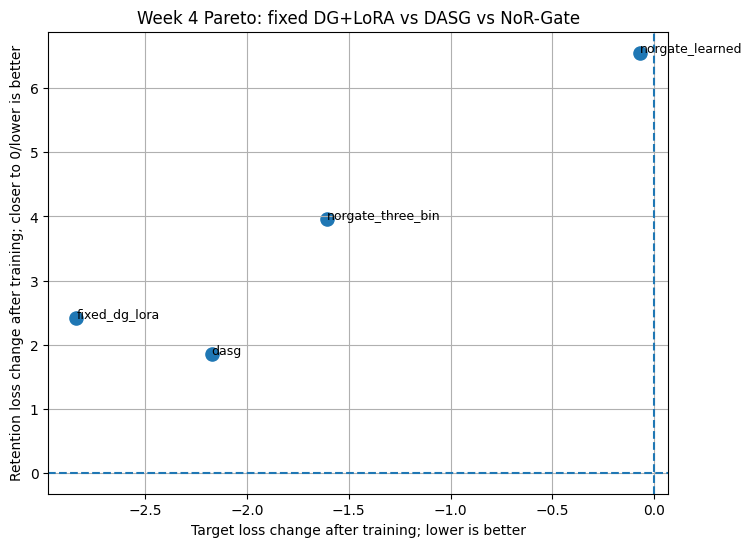

Saved: /content/week4_norgate_pareto/week4_pareto_plot.png


In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(pareto["target_loss_change"], pareto["retention_loss_change"], s=90)
for _, row in pareto.iterrows():
    plt.text(row["target_loss_change"], row["retention_loss_change"], row["method"], fontsize=9)
plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle="--")
plt.xlabel("Target loss change after training; lower is better")
plt.ylabel("Retention loss change after training; closer to 0/lower is better")
plt.title("Week 4 Pareto: fixed DG+LoRA vs DASG vs NoR-Gate")
plt.grid(True)
pareto_plot_path = OUT_DIR / "week4_pareto_plot.png"
plt.savefig(pareto_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", pareto_plot_path)

## 14. Lambda and gate diagnostics

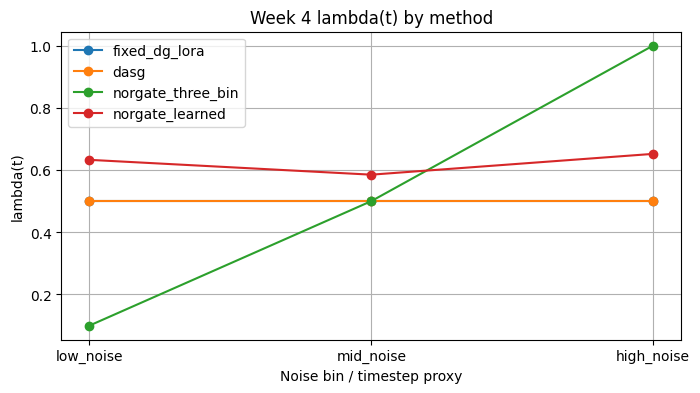

Saved: /content/week4_norgate_pareto/week4_lambda_by_noise_bin.png


,method,noise_bin,mean_gate_entropy,mean_frozen_branch_usage,mean_trainable_branch_usage
0,dasg,high_noise,0.365336,0.880796,0.119204
1,dasg,low_noise,0.662848,0.622457,0.377543
2,dasg,mid_noise,0.582204,0.731057,0.268943
3,fixed_dg_lora,high_noise,0.365338,0.880795,0.119205
4,fixed_dg_lora,low_noise,0.662848,0.622458,0.377542
5,fixed_dg_lora,mid_noise,0.582204,0.731057,0.268943
6,norgate_learned,high_noise,0.365336,0.880796,0.119204
7,norgate_learned,low_noise,0.662834,0.622487,0.377513
8,norgate_learned,mid_noise,0.582099,0.731163,0.268837
9,norgate_three_bin,high_noise,0.365245,0.880842,0.119158


Saved: /content/week4_norgate_pareto/week4_gate_diagnostics_by_noise.csv


In [15]:
lambda_plot_path = OUT_DIR / "week4_lambda_by_noise_bin.png"
plt.figure(figsize=(8, 4))
for method in lambda_df["method"].unique():
    sub = lambda_df[lambda_df["method"] == method]
    plt.plot(sub["noise_bin"], sub["lambda_value"], marker="o", label=method)
plt.xlabel("Noise bin / timestep proxy")
plt.ylabel("lambda(t)")
plt.title("Week 4 lambda(t) by method")
plt.legend(); plt.grid(True)
plt.savefig(lambda_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", lambda_plot_path)

gate_diag = eval_df[eval_df["phase"] == "after"].groupby(["method", "noise_bin"]).agg(
    mean_gate_entropy=("gate_entropy", "mean"),
    mean_frozen_branch_usage=("frozen_branch_usage", "mean"),
    mean_trainable_branch_usage=("trainable_branch_usage", "mean"),
).reset_index()
gate_diag_path = OUT_DIR / "week4_gate_diagnostics_by_noise.csv"
gate_diag.to_csv(gate_diag_path, index=False)
display(gate_diag)
print("Saved:", gate_diag_path)

## 15. Internal note and reproducibility report

In [16]:
best_method = pareto.iloc[0]["method"]
internal_note = f"""# Week 4 Internal Note: NoR-Gate

## Setup
- Model: {MODEL_NAME}
- Quantization: 4-bit NF4
- Domains: {list(DOMAINS.keys())}
- Retention domain: general toy examples
- Methods compared: {list(METHODS.keys())}
- DASG layers: {DASG_LAYERS}
- Fixed late layers: {FIXED_LATE_LAYERS}
- Train steps per method: {TRAIN_STEPS}

## Implemented components
1. Three-bin λ(t) schedule:
   - low_noise: {THREE_BIN_LAMBDA['low_noise']}
   - mid_noise: {THREE_BIN_LAMBDA['mid_noise']}
   - high_noise: {THREE_BIN_LAMBDA['high_noise']}

2. Learned bounded λ(t):
   - Tiny MLP taking mask probability and noise-bin one-hot features.
   - Output constrained to [{LAMBDA_MIN}, {LAMBDA_MAX}].

3. Gate regularizers:
   - Frozen-branch anchor: -log(alpha_frozen)
   - Entropy regularizer: H(alpha_frozen, alpha_grown)

## Pareto result
The best method by proxy score was: **{best_method}**.

The proxy score rewards target-domain loss reduction and penalizes retention loss increase. The Pareto table and plot are the main Week 4 comparison between fixed DG+LoRA, DASG, and NoR-Gate variants.

## Limitation
This is a small Colab/T4 implementation on toy domains. It implements real DG+LoRA gates and real gate regularizers, but results should be confirmed with more steps, more seeds, and the final small LLaDA checkpoint.
"""
internal_note_path = OUT_DIR / "week4_internal_note.md"
with open(internal_note_path, "w") as f: f.write(internal_note)
report = {
    "week": 4,
    "task": "NoR-Gate: three-bin lambda(t), learned bounded lambda(t), and gate regularizers",
    "model": MODEL_NAME,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "quantization": "4-bit NF4",
    "max_length": MAX_LENGTH,
    "train_steps": TRAIN_STEPS,
    "dasg_layers": DASG_LAYERS,
    "fixed_late_layers": FIXED_LATE_LAYERS,
    "three_bin_lambda": THREE_BIN_LAMBDA,
    "learned_lambda_bounds": {"lambda_min": LAMBDA_MIN, "lambda_max": LAMBDA_MAX},
    "gate_regularizers": {"frozen_anchor": "-log(alpha_frozen)", "entropy": "H(alpha_frozen, alpha_grown)", "beta_frozen_anchor": BETA_FROZEN_ANCHOR, "beta_entropy": BETA_ENTROPY},
    "methods": METHODS,
    "best_proxy_method": best_method,
    "outputs": {
        "eval_log": str(eval_path), "train_log": str(train_path), "lambda_values": str(lambda_path), "method_meta": str(meta_path),
        "phase_summary": str(phase_summary_path), "loss_change": str(loss_change_path), "pareto_table": str(pareto_path),
        "pareto_plot": str(pareto_plot_path), "lambda_plot": str(lambda_plot_path), "gate_diagnostics": str(gate_diag_path),
        "internal_note": str(internal_note_path),
    },
    "limitation": "Small Colab/T4 toy-domain implementation with real DG+LoRA gates; rerun with more seeds, more steps, and final small LLaDA checkpoint."
}
report_path = OUT_DIR / "week4_reproducibility_report.json"
with open(report_path, "w") as f: json.dump(report, f, indent=2)
print("Saved:", internal_note_path)
print("Saved:", report_path)
print(internal_note)
print(json.dumps(report, indent=2))

Saved: /content/week4_norgate_pareto/week4_internal_note.md
Saved: /content/week4_norgate_pareto/week4_reproducibility_report.json
# Week 4 Internal Note: NoR-Gate

## Setup
- Model: inclusionAI/LLaDA-MoE-7B-A1B-Instruct
- Quantization: 4-bit NF4
- Domains: ['code_toy', 'math_toy', 'qa_toy']
- Retention domain: general toy examples
- Methods compared: ['fixed_dg_lora', 'dasg', 'norgate_three_bin', 'norgate_learned']
- DASG layers: [15, 14, 13, 12, 11]
- Fixed late layers: [11, 12, 13, 14, 15]
- Train steps per method: 3

## Implemented components
1. Three-bin λ(t) schedule:
   - low_noise: 0.1
   - mid_noise: 0.5
   - high_noise: 1.0

2. Learned bounded λ(t):
   - Tiny MLP taking mask probability and noise-bin one-hot features.
   - Output constrained to [0.05, 1.25].

3. Gate regularizers:
   - Frozen-branch anchor: -log(alpha_frozen)
   - Entropy regularizer: H(alpha_frozen, alpha_grown)

## Pareto result
The best method by proxy score was: **fixed_dg_lora**.

The proxy score rewards

## 16. Expected Week 4 outputs

```text
/content/week4_norgate_pareto/week4_eval_log.csv
/content/week4_norgate_pareto/week4_train_log.csv
/content/week4_norgate_pareto/week4_lambda_values.csv
/content/week4_norgate_pareto/week4_method_meta.json
/content/week4_norgate_pareto/week4_phase_summary.csv
/content/week4_norgate_pareto/week4_before_after_loss_change.csv
/content/week4_norgate_pareto/week4_pareto_table.csv
/content/week4_norgate_pareto/week4_pareto_plot.png
/content/week4_norgate_pareto/week4_lambda_by_noise_bin.png
/content/week4_norgate_pareto/week4_gate_diagnostics_by_noise.csv
/content/week4_norgate_pareto/week4_internal_note.md
/content/week4_norgate_pareto/week4_reproducibility_report.json
```

Report paragraph:

```text
Week 4 implemented NoR-Gate on top of the DG+LoRA/DASG scaffold. The experiment compared fixed DG+LoRA, DASG-selected DG+LoRA, NoR-Gate with a three-bin λ(t) schedule, and NoR-Gate with learned bounded λ(t). The three-bin schedule assigned different retention weights to low, mid, and high noise bins, while the learned λ(t) module used a tiny MLP constrained to [λmin, λmax]. The DG+LoRA wrapper exposed real frozen/trainable branch gates, enabling actual gate regularization through a frozen-branch anchor term and gate-entropy term. The final deliverable is a Pareto plot and Pareto table comparing target-domain loss improvement against retention loss change across fixed DG+LoRA, DASG, and NoR-Gate variants.
```
